# Решающие деревья

#  I. Немного решающих деревьев
##### Задача 1. Построение "среднего" алгоритма
В этом задании вам нужно построить графики, демонстрирующие, как алгоритм аппроксимирует истинную зависимость в данных и как он меняется в зависимости от гиперпараметров метода обучения.

In [30]:
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline

In [31]:
def f(x):
    return np.sin(x)   # истинная зависимость в данных
sample_size = 100      # длина выборки
samples_num = 20       # количество выборок
linspace = np.linspace(0, 7, 1000)  # точки для построения графиков

__1. (2 балла)__
1. Сгенерируйте выборку $x$ из одномерного экспоненциального распределения (np.random.exponential) длины sample_size.
1. Создайте вектор целевых переменных $y$ как сумму $f(x)$ и случайного шума, сгенерированного из равномерного распределения на отрезке $[-1, 1]$ (np.random.uniform).
1. Обучите DecisionTreeRegressor с параметрами по умолчанию на полученной выборке и сделайте предсказания для объектов из linspace.
1. Постройте два графика на одном рисунке: $f(x)$ и зависимость, восстановленную решающим деревом.

    Рекомендация: не забудьте, что все методы обучения в sklearn требуют на вход двумерную матрицу объекты-признаки. Сделать такую из одномерного вектора можно добавлением мнимых осей (np.newaxis).

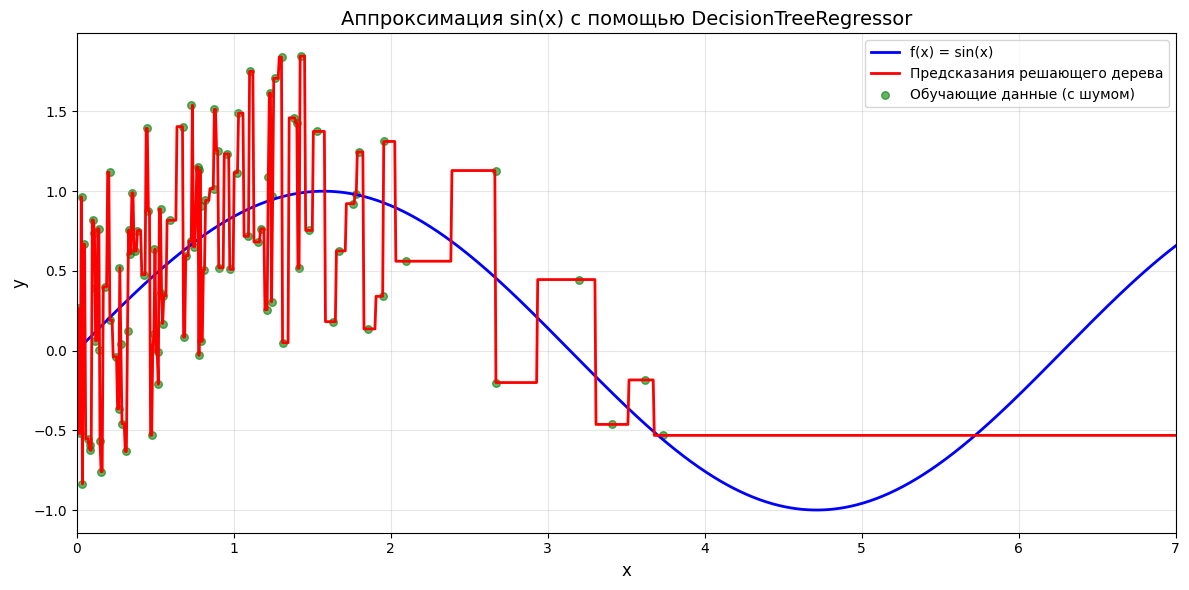

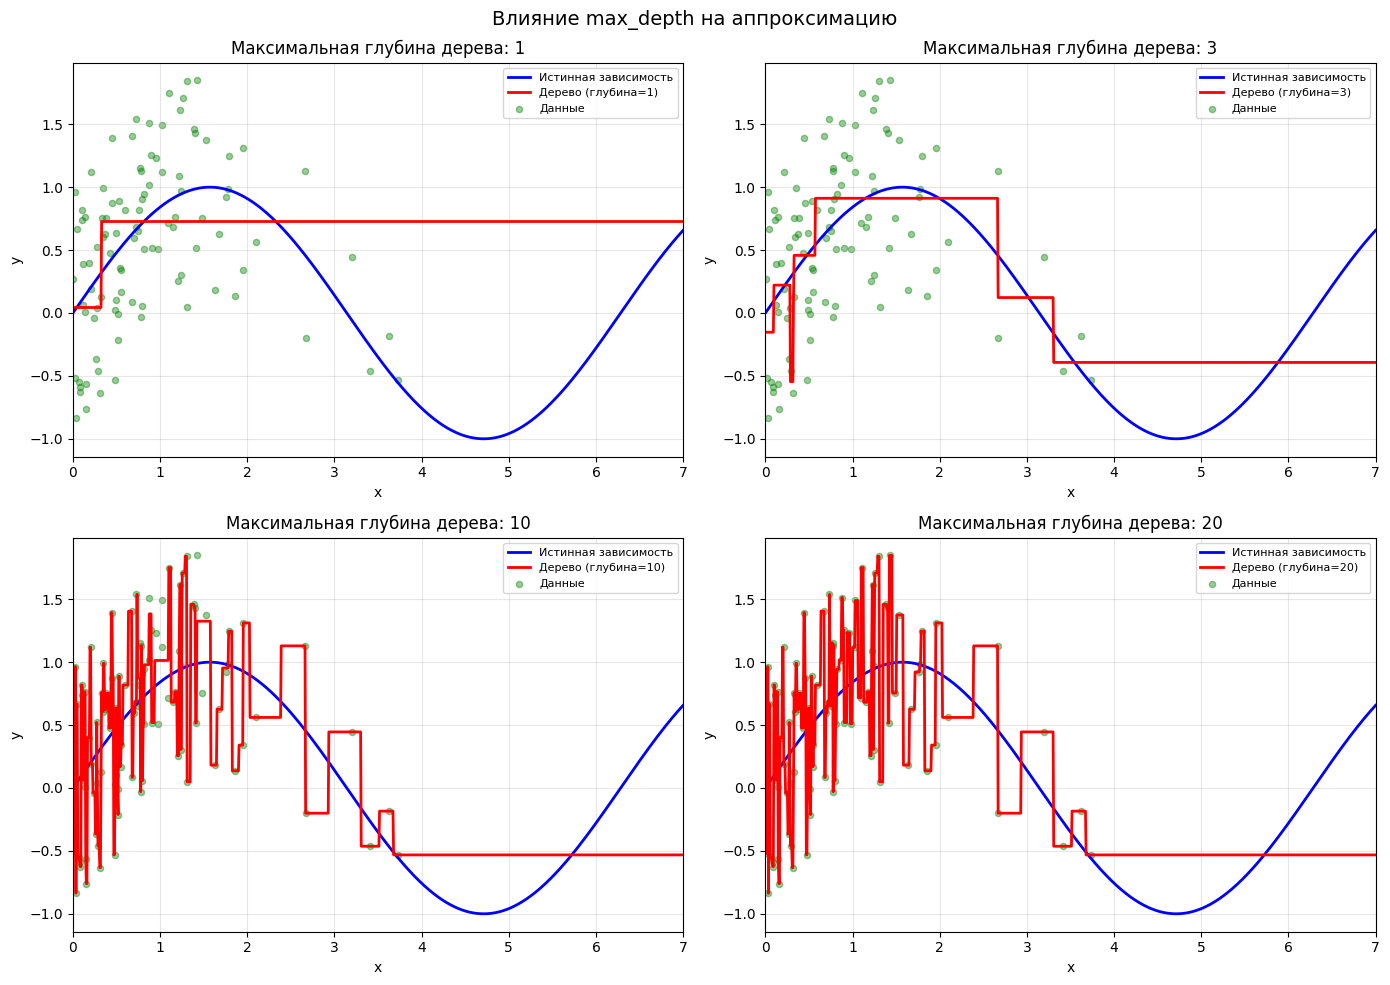

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor


np.random.seed(239239)
x = np.random.exponential(scale=1.0, size=sample_size)

y = f(x) + np.random.uniform(low=-1, high=1, size=sample_size)

x_2d = x[:, np.newaxis]

tree = DecisionTreeRegressor(random_state=42)
tree.fit(x_2d, y)

linspace_2d = linspace[:, np.newaxis]
y_pred = tree.predict(linspace_2d)

plt.figure(figsize=(12, 6))

plt.plot(linspace, f(linspace), 'b-', linewidth=2, label='f(x) = sin(x)')
plt.plot(linspace, y_pred, 'r-', linewidth=2, label='Предсказания решающего дерева')

plt.scatter(x, y, c='green', alpha=0.6, s=30, label='Обучающие данные (с шумом)')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Аппроксимация sin(x) с помощью DecisionTreeRegressor', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 7])

plt.tight_layout()
plt.show()


depths = [1, 3, 10, 20]
plt.figure(figsize=(14, 10))

for i, depth in enumerate(depths, 1):
    plt.subplot(2, 2, i)
    
    tree_depth = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree_depth.fit(x_2d, y)
    y_pred_depth = tree_depth.predict(linspace_2d)
    
    plt.plot(linspace, f(linspace), 'b-', linewidth=2, label='Истинная зависимость')
    plt.plot(linspace, y_pred_depth, 'r-', linewidth=2, label=f'Дерево (глубина={depth})')
    plt.scatter(x, y, c='green', alpha=0.4, s=20, label='Данные')
    
    plt.xlabel('x', fontsize=10)
    plt.ylabel('y', fontsize=10)
    plt.title(f'Максимальная глубина дерева: {depth}', fontsize=12)
    plt.legend(loc='best', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 7])

plt.suptitle('Влияние max_depth на аппроксимацию', fontsize=14)
plt.tight_layout()
plt.show()

__2. (1 балл)__

Повторите первые 3 шага, описанные выше, samples_num раз. На одном графике для каждого обученного решающего дерева визуализируйте восстановленную им зависимость (рекомендуется все такие линии рисовать полупрозрачными и серым цветом: plt.plot(...... color="gray", alpha=0.5)).  На этом же графике изобразите истинную зависимость f(x) (красным цветом: color="red") и усредненную по всем деревьям восстановленную зависимость (черным цветом: color="black").    

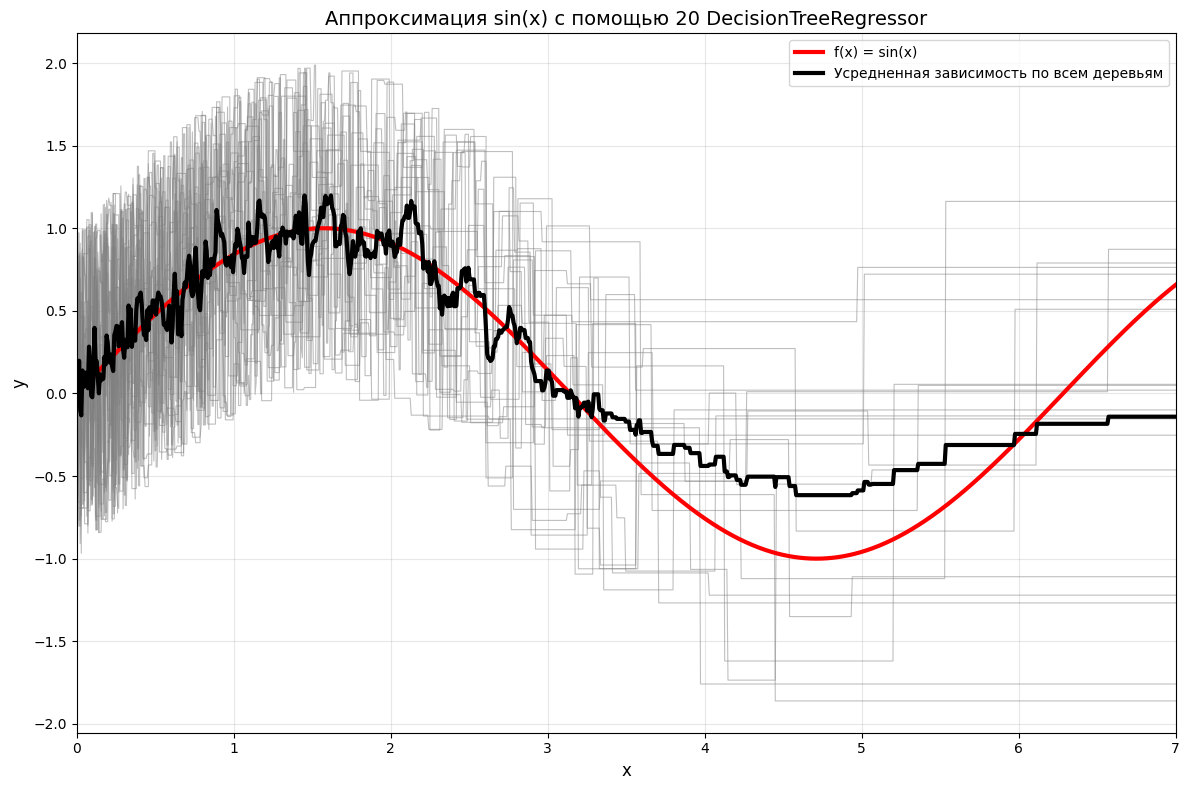

Количество деревьев: 20
Среднее MSE по отдельным деревьям: 0.5251
MSE усредненной зависимости: 0.0764
Улучшение при усреднении: 85.5%


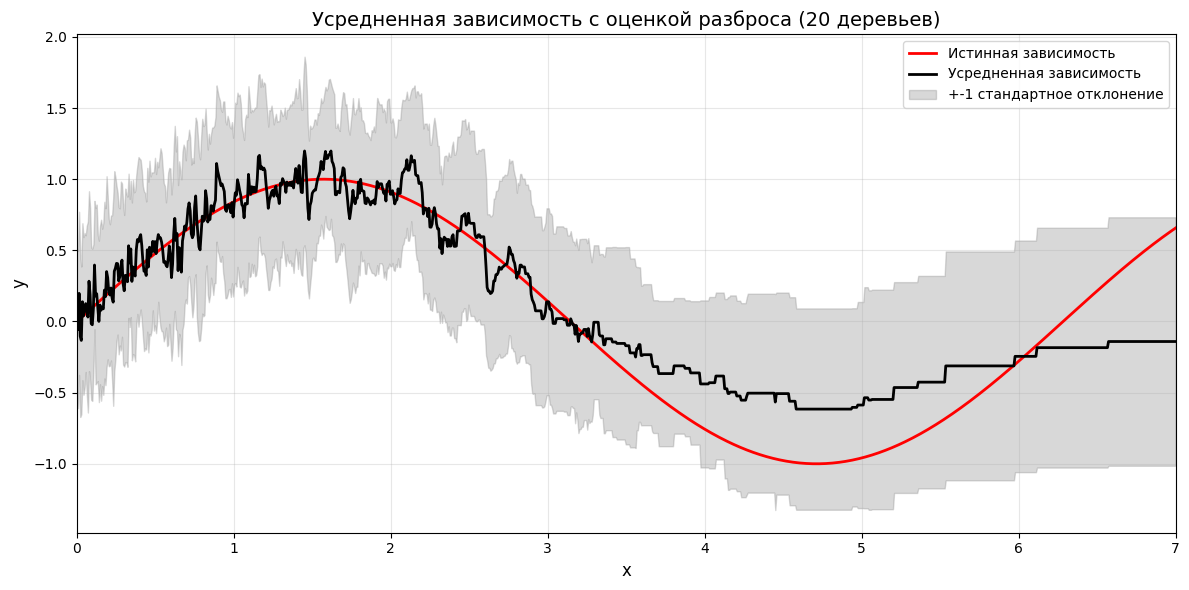

In [33]:
linspace_2d = linspace[:, np.newaxis]
all_predictions = np.zeros((samples_num, len(linspace)))

plt.figure(figsize=(12, 8))

for i in range(samples_num):
    x = np.random.exponential(scale=1.0, size=sample_size)
    y = f(x) + np.random.uniform(low=-1, high=1, size=sample_size)

    x_2d = x[:, np.newaxis]
    
    tree = DecisionTreeRegressor(random_state=42+i)
    tree.fit(x_2d, y)
    
    y_pred = tree.predict(linspace_2d)
    all_predictions[i] = y_pred
    
    plt.plot(linspace, y_pred, color="gray", alpha=0.5, linewidth=0.8)

average_prediction = np.mean(all_predictions, axis=0)

plt.plot(linspace, f(linspace), color="red", linewidth=3, label='f(x) = sin(x)')
plt.plot(linspace, average_prediction, color="black", linewidth=3, label='Усредненная зависимость по всем деревьям')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'Аппроксимация sin(x) с помощью {samples_num} DecisionTreeRegressor', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 7])

plt.tight_layout()
plt.show()

mse_individual = np.mean((all_predictions - f(linspace)[np.newaxis, :])**2, axis=1)
mse_average = np.mean((average_prediction - f(linspace))**2)

print(f"Количество деревьев: {samples_num}")
print(f"Среднее MSE по отдельным деревьям: {np.mean(mse_individual):.4f}")
print(f"MSE усредненной зависимости: {mse_average:.4f}")
print(f"Улучшение при усреднении: {100*(np.mean(mse_individual)-mse_average)/np.mean(mse_individual):.1f}%")

plt.figure(figsize=(12, 6))

std_predictions = np.std(all_predictions, axis=0)

plt.plot(linspace, f(linspace), 'r-', linewidth=2, label='Истинная зависимость')

plt.plot(linspace, average_prediction, 'k-', linewidth=2, label='Усредненная зависимость')
plt.fill_between(linspace, 
                 average_prediction - std_predictions, 
                 average_prediction + std_predictions, 
                 alpha=0.3, color='gray', label='+-1 стандартное отклонение')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'Усредненная зависимость с оценкой разброса ({samples_num} деревьев)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 7])

plt.tight_layout()
plt.show()

__3.(0.5 балл):__
Повторите предыдущий пункт, установив максимальную глубину решающего дерева равной 2, а затем равной 4. Таким образом, у вас получится еще два графика.


1. МАКСИМАЛЬНАЯ ГЛУБИНА = 2


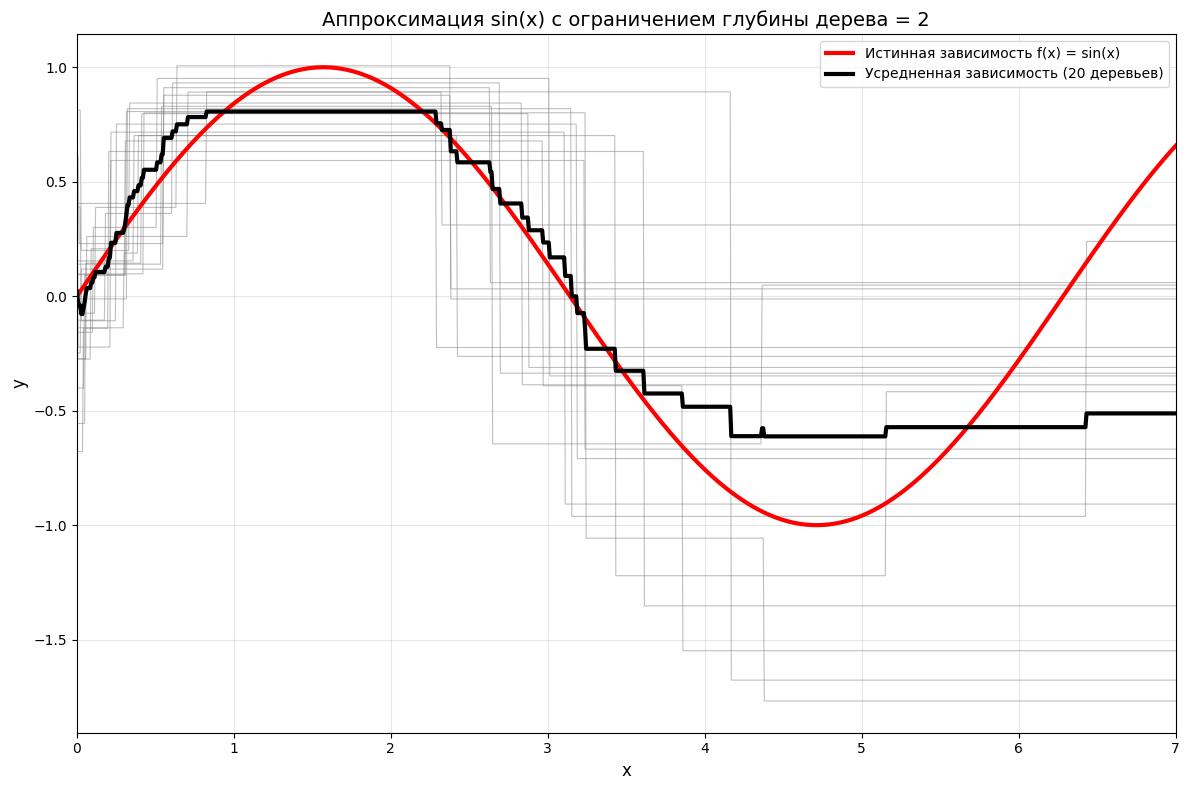

Максимальная глубина: 2
Среднее MSE по отдельным деревьям: 0.3432
MSE усредненной зависимости: 0.1198
Средняя глубина деревьев: 2.0
--------------------------------------------------

2. МАКСИМАЛЬНАЯ ГЛУБИНА = 4


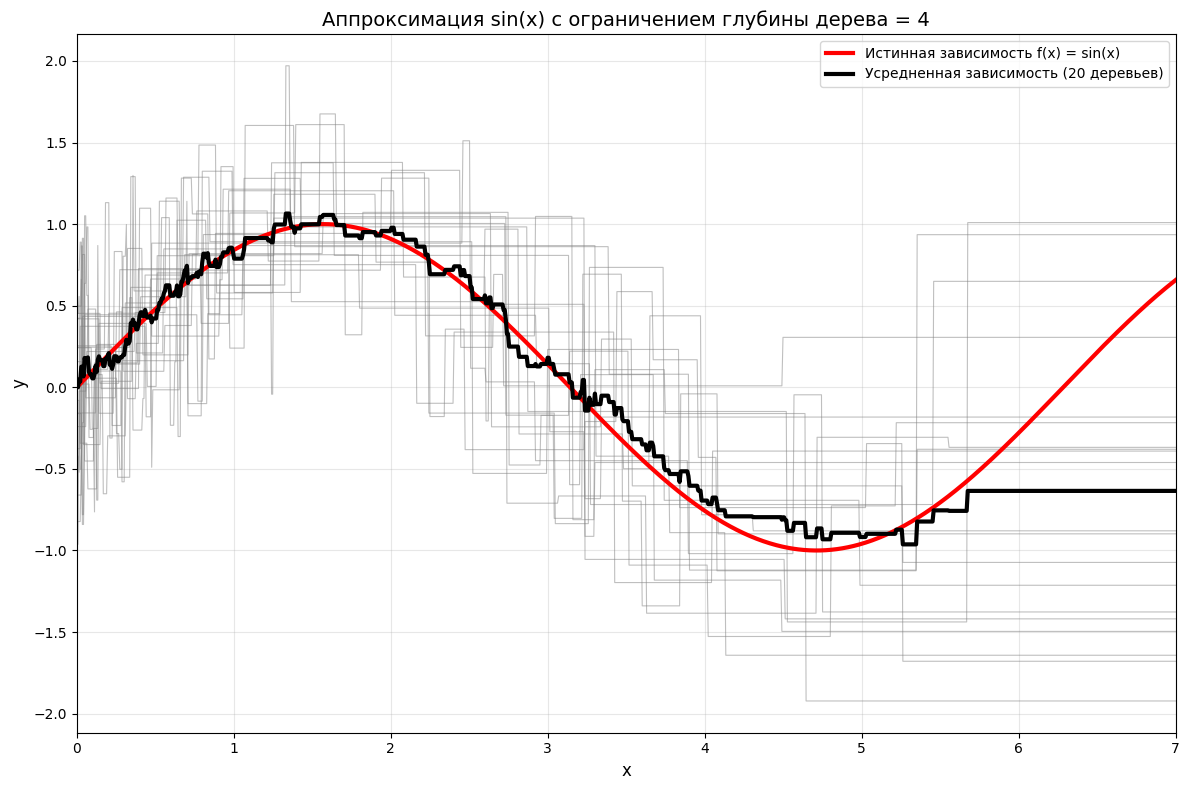

Максимальная глубина: 4
Среднее MSE по отдельным деревьям: 0.4317
MSE усредненной зависимости: 0.1202
Средняя глубина деревьев: 4.0
--------------------------------------------------

3. БЕЗ ОГРАНИЧЕНИЯ ГЛУБИНЫ
Среднее MSE по отдельным деревьям: 0.4531
MSE усредненной зависимости: 0.1319
Средняя глубина деревьев: 16.85


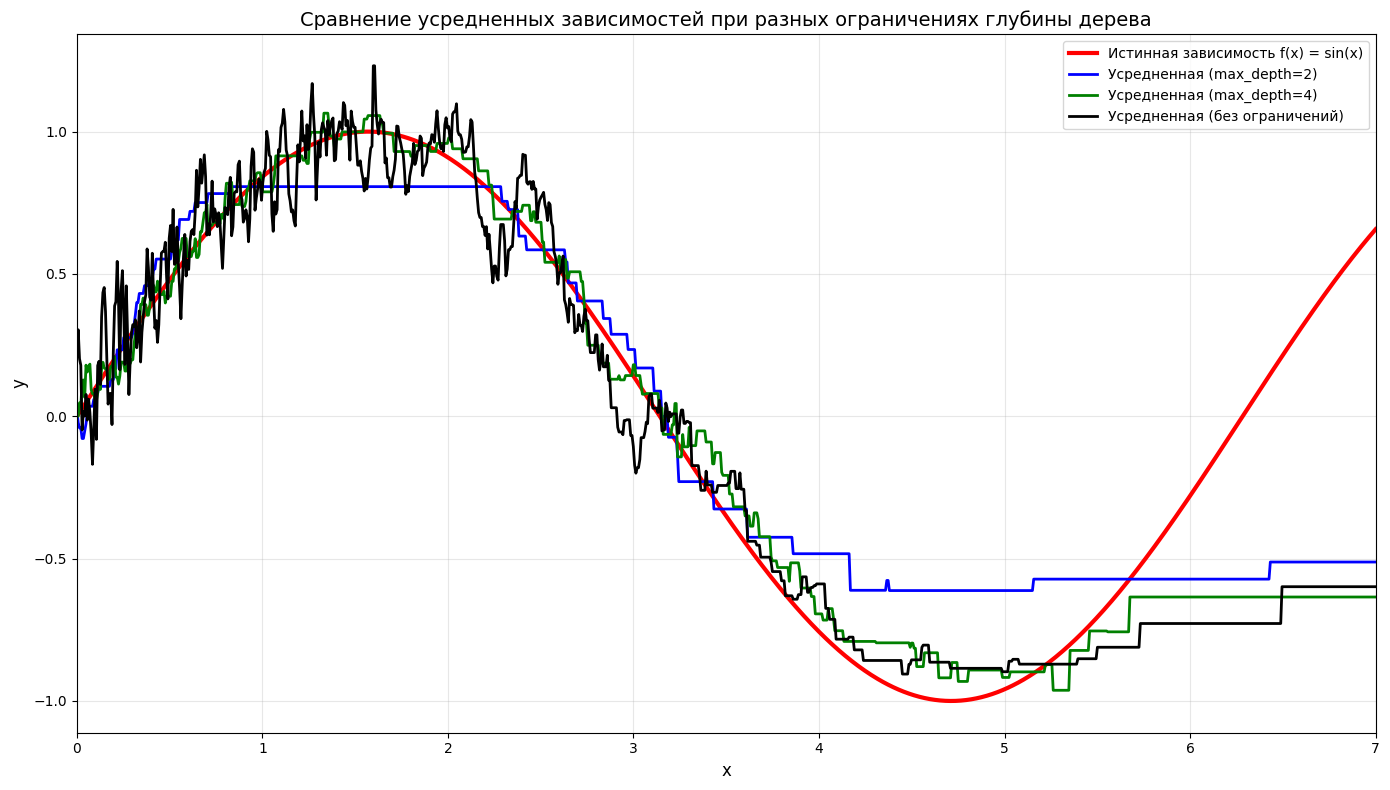

In [34]:
def plot_tree_depth_experiment(max_depth, title_suffix):
    all_predictions = np.zeros((samples_num, len(linspace)))
    
    plt.figure(figsize=(12, 8))
    
    for i in range(samples_num):
        x = np.random.exponential(scale=1.0, size=sample_size)
        y = f(x) + np.random.uniform(low=-1, high=1, size=sample_size)
        x_2d = x[:, np.newaxis]
        
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=42+i)
        tree.fit(x_2d, y)
        
        y_pred = tree.predict(linspace_2d)
        all_predictions[i] = y_pred

        plt.plot(linspace, y_pred, color="gray", alpha=0.5, linewidth=0.8)
    
    average_prediction = np.mean(all_predictions, axis=0)
    
    plt.plot(linspace, f(linspace), color="red", linewidth=3, label='Истинная зависимость f(x) = sin(x)')
    plt.plot(linspace, average_prediction, color="black", linewidth=3, label=f'Усредненная зависимость ({samples_num} деревьев)')
    
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.title(f'Аппроксимация sin(x) с ограничением глубины дерева = {max_depth}', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 7])
    
    plt.tight_layout()
    plt.show()
    
    mse_individual = np.mean((all_predictions - f(linspace)[np.newaxis, :])**2, axis=1)
    mse_average = np.mean((average_prediction - f(linspace))**2)
    
    print(f"Максимальная глубина: {max_depth}")
    print(f"Среднее MSE по отдельным деревьям: {np.mean(mse_individual):.4f}")
    print(f"MSE усредненной зависимости: {mse_average:.4f}")
    print(f"Средняя глубина деревьев: {np.mean([tree.get_depth() for _ in range(samples_num)])}")
    print("-" * 50)
    
    return average_prediction, np.mean(mse_individual), mse_average

print("\n1. МАКСИМАЛЬНАЯ ГЛУБИНА = 2")
pred_depth_2, mse_ind_2, mse_avg_2 = plot_tree_depth_experiment(max_depth=2, title_suffix="(max_depth=2)")

print("\n2. МАКСИМАЛЬНАЯ ГЛУБИНА = 4")
pred_depth_4, mse_ind_4, mse_avg_4 = plot_tree_depth_experiment(max_depth=4, title_suffix="(max_depth=4)")

print("\n3. БЕЗ ОГРАНИЧЕНИЯ ГЛУБИНЫ")
all_predictions_unlimited = np.zeros((samples_num, len(linspace)))

for i in range(samples_num):
    x = np.random.exponential(scale=1.0, size=sample_size)
    y = f(x) + np.random.uniform(low=-1, high=1, size=sample_size)
    x_2d = x[:, np.newaxis]
    
    tree = DecisionTreeRegressor(random_state=42+i)
    tree.fit(x_2d, y)
    
    y_pred = tree.predict(linspace_2d)
    all_predictions_unlimited[i] = y_pred

average_prediction_unlimited = np.mean(all_predictions_unlimited, axis=0)
mse_ind_unlimited = np.mean((all_predictions_unlimited - f(linspace)[np.newaxis, :])**2, axis=1)
mse_avg_unlimited = np.mean((average_prediction_unlimited - f(linspace))**2)

print(f"Среднее MSE по отдельным деревьям: {np.mean(mse_ind_unlimited):.4f}")
print(f"MSE усредненной зависимости: {mse_avg_unlimited:.4f}")
print(f"Средняя глубина деревьев: {np.mean([DecisionTreeRegressor(random_state=42+i).fit(
    np.random.exponential(scale=1.0, size=sample_size)[:, np.newaxis], 
    f(np.random.exponential(scale=1.0, size=sample_size)) + np.random.uniform(low=-1, high=1, size=sample_size)
).get_depth() for i in range(samples_num)])}")

plt.figure(figsize=(14, 8))

plt.plot(linspace, f(linspace), 'r-', linewidth=3, label='Истинная зависимость f(x) = sin(x)')
plt.plot(linspace, pred_depth_2, 'b-', linewidth=2, label='Усредненная (max_depth=2)')
plt.plot(linspace, pred_depth_4, 'g-', linewidth=2, label='Усредненная (max_depth=4)')
plt.plot(linspace, average_prediction_unlimited, 'k-', linewidth=2, label='Усредненная (без ограничений)')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Сравнение усредненных зависимостей при разных ограничениях глубины дерева', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 7])

plt.tight_layout()
plt.show()

__4. (0.5 балла)__ Что можно сказать о смещении решающих деревьев, исходя из проведенного эксперимента? В каких из трех рассмотренных случаев (без ограничения на глубину дерева и с ограничением 2 и 4) можно утверждать, что смещение решающего дерева близко к нулю?

**Ответ:**

### II. Решающие деревья чужими руками

#### Задача 3.
В этой части вам нужно посмотреть на класс написанный за вас для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__8. (1 балл)__

Загрузите таблицу [students.csv](https://drive.google.com/file/d/0B2zoFVYw1rN3a0d0Zm43TzQ4aUU/view?usp=sharing) (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

In [35]:
import pandas as pd
data = pd.read_csv('students.csv')
data.head()

,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,0
1,0.08,0.08,0.10,0.24,0.90,1
2,0.06,0.06,0.05,0.25,0.33,0
3,0.10,0.10,0.15,0.65,0.30,1
4,0.08,0.08,0.08,0.98,0.24,0


In [36]:
from importlib import reload
from matplotlib import pyplot as plt
import hw3code
reload(hw3code)

<module 'hw3code' from '/home/alex-rus/Projects/MachineLearning/task7_dstree_practice/hw3code.py'>

In [37]:
plt.figure()
x, y, bx, by = hw3code.find_best_split #code here

TypeError: cannot unpack non-iterable function object

<Figure size 640x480 with 0 Axes>

__9. (1 балл)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:**

__10. (1 балл)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (из [Data Folder](https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/)), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [ ]:
#code here

### IIII. Композиции деревьев
#### Задача 4. Сравнение композиционных методов над решающими деревьями
__11. (1 балл)__

Загрузите датасет из соревнования [BNP Paribas Cardif Claims Management](https://www.kaggle.com/c/bnp-paribas-cardif-claims-management/leaderboard). Возьмите из него первые 10к объектов, оставьте только вещественные признаки, а пропуски замените нулями. Разбейте выборку на обучение и контроль в соотношении 7:3.

1. С помощью cross_val_score с cv=3 оцените качество (accuracy) следующих классификаторов на обучающей выборке:
    * DecisionTreeClassifier
    * BaggingClassifier со 100 деревьями
    * RandomForestClassifier со 100 деревьями
    
Значение получается шумное, но в целом у вас должно получиться, что качество возрастает с каждым следующим алгоритмом (если это не так, то посмотрите как ведут себя алгоритмы с разными сидами в кроссвалидации и самих алгоритмах). Этот пример демонстрирует, что RandomForest — это более сложный алгоритм, чем бэггинг.

In [ ]:
#code here

#### Задача 5. Число деревьев в случайном лесе
В этой задаче мы рассмотрим, переобучаются ли композиционные алгоритмы с увеличением числа деревьев.

__12. (1 балл)__

Переберите значения от 20 до 1000-5000 деревьев с шагом 20, посчитайте accuracy на тестовой выборке для каждого числа деревьев и постройте график зависимости качества от числа деревьев.

Рекомендация.

Если каждый раз обучать RandomForest с нуля, придётся обучить в общей сумме $20 + 200 + \ldots + 5000$ деревьев.
Однако, как мы знаем, деревья в случайных лесах строятся независимо и параллельно, поэтому можно обучить всего 5000 деревьев.

Для этого в при создании объекта класса RandomForestClassifier нужно указать в том числе warm_start=True. Затем обучить алгоритм с помощью метода fit, использовать метод predict для классификации. После этого с помощью метода set_params изменить параметр n_estimators. Если к полученному объекту применить метод fit, внутри него будет обучаться только недостающее число деревьев.

Переобучается ли случайный лес с увеличением числа деревьев?

In [ ]:
#code here